# Heart Disease Model Comparison Notebook


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
df=pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
df.shape

(918, 12)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

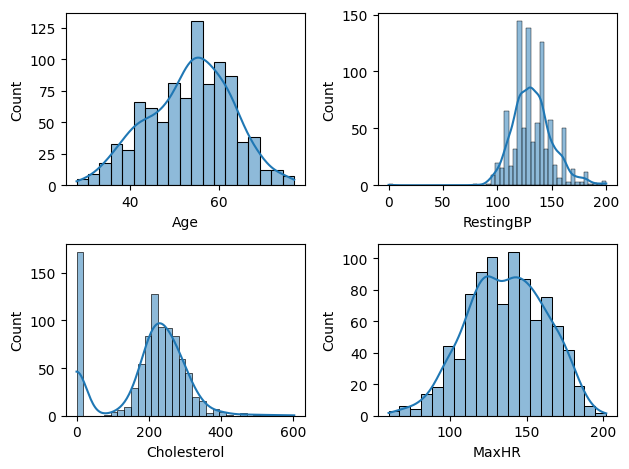

In [8]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

In [9]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [10]:
# In the above plotting there is RestingBP of 0 which is not possible which is wrong data entry.
# There are a lot of people with 0 cholesterol which is wrong data entry. 
# ( Maybe the data set has provided null values as 0, it can be wrong for model training/feeding)
# We need to preprocess it 
# We would calculate mean of the column
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()  # loc means targetting rows

In [11]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [12]:
resting_bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, resting_bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [13]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


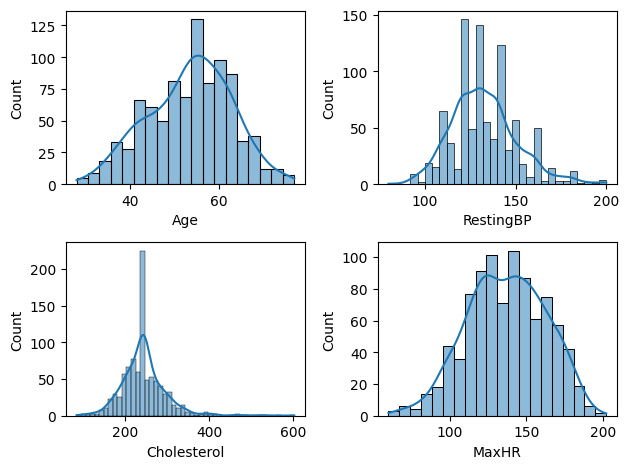

In [14]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True)

plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: >

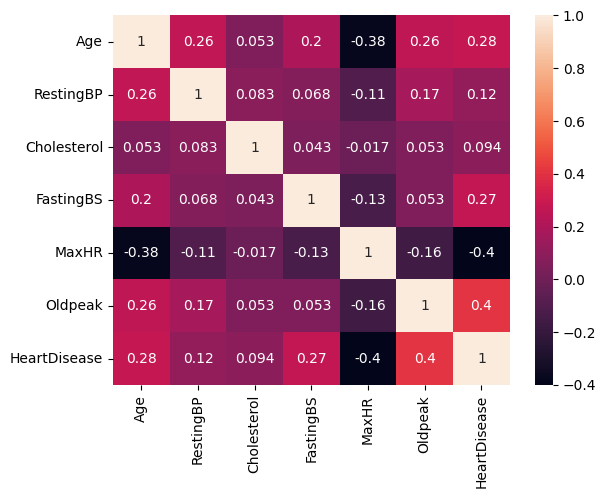

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [16]:
# One-hot encode categorical columns
categorical_cols = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

df_encode = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)


In [17]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,GradientBoostingClassifier,VotingClassifier

from xgboost import XGBClassifier

# Features and target
X = df_encode.drop("HeartDisease", axis=1)
y = df_encode["HeartDisease"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

std=StandardScaler()
X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)

mm=MinMaxScaler()
X_train_mm=mm.fit_transform(X_train)
X_test_mm=mm.transform(X_test)

In [19]:

models_scaled={
"LogReg":LogisticRegression(solver="liblinear",C=1,random_state=42),
"SVC":SVC(kernel="rbf",C=2,probability=True,random_state=42),
"KNN":KNeighborsClassifier(n_neighbors=7,weights="distance"),
"MultinomialNB":MultinomialNB(alpha=0.5)
}
models_tree={
"DecisionTree":DecisionTreeClassifier(max_depth=6,random_state=42),
"RandomForest":RandomForestClassifier(n_estimators=300,random_state=42),
"AdaBoost":AdaBoostClassifier(n_estimators=200,learning_rate=0.5,random_state=42),
"Bagging":BaggingClassifier(n_estimators=200,random_state=42),
"ExtraTrees":ExtraTreesClassifier(n_estimators=300,random_state=42),
"GradientBoost":GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,random_state=42),
"XGBoost":XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=3,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=42)
}

results=[]

for name,m in models_scaled.items():
    data=(X_train_mm,X_test_mm) if name=="MultinomialNB" else (X_train_std,X_test_std)
    m.fit(data[0],y_train)
    pred=m.predict(data[1])
    proba=m.predict_proba(data[1])[:,1]
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred),
        "ROC_AUC":roc_auc_score(y_test,proba)
    })

for name,m in models_tree.items():
    m.fit(X_train,y_train)
    pred=m.predict(X_test)
    if hasattr(m,"predict_proba"):
        proba=m.predict_proba(X_test)[:,1]
    else:
        proba=pred
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred),
        "ROC_AUC":roc_auc_score(y_test,proba)
    })

comparison=pd.DataFrame(results).sort_values(["ROC_AUC","F1"],ascending=False)
print(comparison)


            Model  Accuracy  Precision    Recall        F1   ROC_AUC
2             KNN  0.896739   0.902913  0.911765  0.907317  0.943627
1             SVC  0.858696   0.858491  0.892157  0.875000  0.937351
8      ExtraTrees  0.885870   0.878505  0.921569  0.899522  0.936992
0          LogReg  0.891304   0.894231  0.911765  0.902913  0.933166
5    RandomForest  0.869565   0.890000  0.872549  0.881188  0.929878
10        XGBoost  0.875000   0.898990  0.872549  0.885572  0.928025
6        AdaBoost  0.902174   0.920000  0.901961  0.910891  0.927367
9   GradientBoost  0.875000   0.883495  0.892157  0.887805  0.916906
3   MultinomialNB  0.842391   0.847619  0.872549  0.859903  0.916667
7         Bagging  0.809783   0.845361  0.803922  0.824121  0.899390
4    DecisionTree  0.750000   0.785714  0.754902  0.770000  0.749701


In [20]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import ExtraTreesClassifier
# from xgboost import XGBClassifier

# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     roc_auc_score,
#     confusion_matrix,
#     classification_report
# )

# # Soft Voting Classifier
# voting = VotingClassifier(
#     estimators=[
#         ("svc", SVC(
#             kernel="rbf",
#             C=2,
#             gamma="scale",
#             probability=True,
#             random_state=42
#         )),
#         ("knn", KNeighborsClassifier(
#             n_neighbors=7,
#             weights="distance"
#         )),
#         ("extra", ExtraTreesClassifier(
#             n_estimators=300,
#             random_state=42
#         )),
#         ("xgb", XGBClassifier(
#             n_estimators=300,
#             eval_metric="logloss",
#             random_state=42
#         ))
#     ],
#     voting="soft"
# )

# # Train
# voting.fit(X_train_std, y_train)

# # Predictions
# pred = voting.predict(X_test_std)
# proba = voting.predict_proba(X_test_std)[:, 1]

# # Metrics
# print("Accuracy :", accuracy_score(y_test, pred))
# print("Precision:", precision_score(y_test, pred))
# print("Recall   :", recall_score(y_test, pred))
# print("F1 Score :", f1_score(y_test, pred))
# print("ROC AUC  :", roc_auc_score(y_test, proba))

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, pred))

# print("\nClassification Report:")
# print(classification_report(y_test, pred))

In [ ]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.metrics import *

# voting = VotingClassifier(
#     estimators=[
#         ('ada', AdaBoostClassifier(
#             n_estimators=200,
#             learning_rate=0.5,
#             random_state=42
#         )),
        
#         ('knn', KNeighborsClassifier(
#             n_neighbors=7,
#             weights='distance'
#         )),
        
#         ('lr', LogisticRegression(
#             solver='liblinear',
#             C=1,
#             random_state=42
#         )),
        
#         ('extra', ExtraTreesClassifier(
#             n_estimators=500,
#             random_state=42
#         )),
        
#         ('xgb', XGBClassifier(
#             n_estimators=500,
#             learning_rate=0.03,
#             max_depth=4,
#             eval_metric='logloss',
#             random_state=42
#         ))
#     ],
    
#     voting='soft',
    
#     # Higher weight to better models
#     weights=[4,4,3,3,3]
# )

# voting.fit(X_train_std,y_train)

# pred=voting.predict(X_test_std)
# proba=voting.predict_proba(X_test_std)[:,1]

# print("Accuracy :",accuracy_score(y_test,pred))
# print("Precision:",precision_score(y_test,pred))
# print("Recall   :",recall_score(y_test,pred))
# print("F1 Score :",f1_score(y_test,pred))
# print("ROC AUC  :",roc_auc_score(y_test,proba))

In [22]:
# from sklearn.ensemble import VotingClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# weights_list = [
#     [1,1,1,1,1],
#     [2,2,1,1,1],
#     [3,3,2,2,1],
#     [4,4,3,2,2],
#     [5,4,3,2,2],
#     [5,5,4,3,2],
#     [6,5,4,3,2],
#     [4,4,3,3,3]
# ]

# best_acc = 0
# best_weights = None

# results = []

# for w in weights_list:

#     voting = VotingClassifier(
#         estimators=[
#             ('ada', AdaBoostClassifier(
#                 n_estimators=200,
#                 learning_rate=0.5,
#                 random_state=42
#             )),

#             ('knn', KNeighborsClassifier(
#                 n_neighbors=7,
#                 weights='distance'
#             )),

#             ('lr', LogisticRegression(
#                 solver='liblinear',
#                 C=1,
#                 random_state=42
#             )),

#             ('extra', ExtraTreesClassifier(
#                 n_estimators=500,
#                 random_state=42
#             )),

#             ('xgb', XGBClassifier(
#                 n_estimators=500,
#                 learning_rate=0.03,
#                 max_depth=4,
#                 eval_metric='logloss',
#                 random_state=42
#             ))
#         ],

#         voting='soft',
#         weights=w
#     )

#     voting.fit(X_train_std, y_train)

#     pred = voting.predict(X_test_std)
#     proba = voting.predict_proba(X_test_std)[:,1]

#     acc = accuracy_score(y_test, pred)
#     prec = precision_score(y_test, pred)
#     rec = recall_score(y_test, pred)
#     f1 = f1_score(y_test, pred)
#     roc = roc_auc_score(y_test, proba)

#     results.append([w, acc, prec, rec, f1, roc])

#     if acc > best_acc:
#         best_acc = acc
#         best_weights = w

# print("Best Accuracy :", best_acc)
# print("Best Weights  :", best_weights)

# import pandas as pd

# results_df = pd.DataFrame(
#     results,
#     columns=[
#         "Weights",
#         "Accuracy",
#         "Precision",
#         "Recall",
#         "F1 Score",
#         "ROC AUC"
#     ]
# )

# results_df = results_df.sort_values(by="Accuracy", ascending=False)

# print(results_df)

In [23]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression

# stack = StackingClassifier(

#     estimators=[

#         ('knn',KNeighborsClassifier(
#             n_neighbors=7,
#             weights='distance'
#         )),

#         ('ada',AdaBoostClassifier(
#             n_estimators=200,
#             learning_rate=0.5,
#             random_state=42
#         )),

#         ('extra',ExtraTreesClassifier(
#             n_estimators=500,
#             random_state=42
#         )),

#         ('xgb',XGBClassifier(
#             n_estimators=500,
#             learning_rate=0.03,
#             max_depth=4,
#             eval_metric='logloss',
#             random_state=42
#         ))
#     ],

#     final_estimator=LogisticRegression(),

#     cv=10,

#     n_jobs=-1,

#     passthrough=True
# )

# stack.fit(X_train_std,y_train)

# pred=stack.predict(X_test_std)
# proba=stack.predict_proba(X_test_std)[:,1]

# print("Accuracy :",accuracy_score(y_test,pred))
# print("Precision:",precision_score(y_test,pred))
# print("Recall   :",recall_score(y_test,pred))
# print("F1 Score :",f1_score(y_test,pred))
# print("ROC AUC  :",roc_auc_score(y_test,proba))

In [24]:
# from sklearn.ensemble import StackingClassifier

# stack = StackingClassifier(
#     estimators=[
#         ('knn', KNeighborsClassifier(
#             n_neighbors=7,
#             weights='distance'
#         )),

#         ('ada', AdaBoostClassifier(
#             n_estimators=200,
#             learning_rate=0.5,
#             random_state=42
#         )),

#         ('extra', ExtraTreesClassifier(
#             n_estimators=500,
#             random_state=42
#         )),

#         ('svc', SVC(
#             kernel='rbf',
#             probability=True,
#             C=2,
#             random_state=42
#         ))
#     ],

#     final_estimator=XGBClassifier(
#         n_estimators=300,
#         max_depth=3,
#         learning_rate=0.03,
#         eval_metric='logloss',
#         random_state=42
#     ),

#     cv=10,
#     passthrough=True,
#     n_jobs=-1
# )

# stack.fit(X_train_std, y_train)

# pred = stack.predict(X_test_std)
# proba = stack.predict_proba(X_test_std)[:,1]

# print("Accuracy :",accuracy_score(y_test,pred))
# print("Precision:",precision_score(y_test,pred))
# print("Recall   :",recall_score(y_test,pred))
# print("F1 Score :",f1_score(y_test,pred))
# print("ROC AUC  :",roc_auc_score(y_test,proba))

In [25]:
# import pickle
# from pathlib import Path

# ARTIFACTS = Path("backend/artifacts")
# ARTIFACTS.mkdir(exist_ok=True)

# # Save your best model
# with open(ARTIFACTS / "model.pkl", "wb") as f:
#     pickle.dump(voting, f)          # replace `voting` with your variable

# # Save the StandardScaler
# with open(ARTIFACTS / "scaler.pkl", "wb") as f:
#     pickle.dump(std, f)             # `std` = your fitted StandardScaler

# # Save the post-encoding column list
# with open(ARTIFACTS / "columns.pkl", "wb") as f:
#     pickle.dump(list(X.columns), f) # X = df_encode.drop("HeartDisease", axis=1)

# print("Done! Artifacts saved.")

In [26]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# import shap, pickle
# from pathlib import Path

# ARTIFACTS = Path("backend/artifacts") 

# background = shap.sample(X_train_std, 100)
# pickle.dump(background, open(ARTIFACTS / "background.pkl", "wb"))
# print("Done!")

In [28]:
import shap, pickle
from pathlib import Path

ARTIFACTS = Path("backend/artifacts") 

background = shap.kmeans(X_train_std, 50)
pickle.dump(background, open(ARTIFACTS / "backgroundKmeans.pkl", "wb"))
print("Done!")

Done!
